# Session 2: Homework 1

**Author:** Maksim Gorbuk

**Date:** 25 August 2026

In [1]:
!pip install -q skimpy
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np                 # numpy is a comprehensive library with several mathematical functions
import yfinance as yf              # yfinance fetches stock data directly from Yahoo finance for use in projects
from datetime import datetime      # library with tools for manipulating & handling dates/times
import matplotlib.cm as cm         # colour palettes for visuals
import matplotlib.ticker as mtick  # used in building visuals
import warnings                    # this is used to control how warnings are handled in our project
from skimpy import skim            # Used for generating summary statistics of DataFrames


warnings.filterwarnings('ignore')  # we have decided to suppress all warning messages for this project

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (6.75, 6.75)



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


# Analysis of movies- IMDB dataset

We will look at a subset sample of movies, taken from the [Kaggle IMDB 5000 movie dataset](https://www.kaggle.com/carolzhangdc/imdb-5000-movie-dataset)

In [2]:
# Load movies data

from pathlib import Path

RAW = "https://raw.githubusercontent.com/kostis-christodoulou/am01-code-sep2026/main/data"
local = Path("../data/movies.csv")

movies = pd.read_csv(local if local.exists() else f"{RAW}/movies.csv")



# Printing out information of the dataset

print(movies.info())


# Printing the first few observations of the dataset

movies.head()

skim(movies)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2961 entries, 0 to 2960
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   title                2961 non-null   object 
 1   genre                2961 non-null   object 
 2   director             2961 non-null   object 
 3   year                 2961 non-null   int64  
 4   duration             2961 non-null   int64  
 5   gross                2961 non-null   int64  
 6   budget               2961 non-null   int64  
 7   cast_facebook_likes  2961 non-null   int64  
 8   votes                2961 non-null   int64  
 9   reviews              2961 non-null   int64  
 10  rating               2961 non-null   float64
dtypes: float64(1), int64(7), object(3)
memory usage: 254.6+ KB
None


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 2961   │ │ int64       │ 7     │                                                          │
│ │ Number of columns │ 11     │ │ string      │ 3     │                                                          │
│ └───────────────────┴────────┘ │ float64     │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column      ┃ NA ┃ NA % ┃ mean     ┃ sd       ┃ p0   ┃ p25      ┃ p50      ┃ p75      ┃ p100      ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━┩  │
│ │ year        │  0 │    0 │     2003 │    9.946 │ 1920 │     1999 │     2004 │     2010 │      2016 │     ▃█ │  │
│ │ duration    │  0 │    0 │    109.6 │    22.17 │   37 │       95 │      106 │      119 │       330 │  ▁█▁   │  │
│ │ gross       │  0 │    0 │ 58090000 │ 72470000 │  703 │ 12280000 │ 34700000 │ 75590000 │ 760500000 │   █▁   │  │
│ │ budget      │  0 │    0 │ 40620000 │ 43680000 │  218 │ 11000000 │ 26000000 │ 55000000 │ 300000000 │  █▂▁   │  │
│ │ cast_facebo │  0 │    0 │    12390 │    20530 │    0 │     2241 │     4604 │    16930 │    656700 │   █    │  │
│ │ ok_likes    │    │      │          │          │      │          │          │          │           │        │  │
│ │ votes       │  0 │    0 │   109300 │   158100 │    5 │    19920 │    55750 │   133300 │   1690000 │   █▁   │  │
│ │ reviews     │  0 │    0 │    503.3 │    493.7 │    2 │      199 │      364 │      631 │      5312 │   █▁   │  │
│ │ rating      │  0 │    0 │    6.389 │    1.052 │  1.6 │      5.8 │      6.5 │      7.1 │       9.3 │   ▂█▆▁ │  │
│ └─────────────┴────┴──────┴──────────┴──────────┴──────┴──────────┴──────────┴──────────┴───────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃          ┃    ┃      ┃          ┃           ┃            ┃           ┃ chars per  ┃ words per ┃ total      ┃  │
│ ┃ column   ┃ NA ┃ NA % ┃ shortest ┃ longest   ┃ min        ┃ max       ┃ row        ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ title    │  0 │    0 │ O        │ Borat:    │ 10         │ xXx:      │       15.3 │       2.8 │       8262 │  │
│ │          │    │      │          │ Cultural  │ Cloverfiel │ State of  │            │           │            │  │
│ │          │    │      │          │ Learnings │ d Lane     │ the Union │            │           │            │  │
│ │          │    │      │          │ of        │            │           │            │           │            │  │
│ │          │    │      │          │ America   │            │           │            │           │            │  │
│ │          │    │      │          │ for Make  │            │           │            │           │            │  │
│ │          │    │      │          │ Benefit   │       

Besides the obvious variables of title, genre, director, year, and duration, the rest of the variables are as follows:

- gross : The gross earnings in the US box office, not adjusted for inflation

- budget: The movie's budget

- cast_facebook_likes: the number of facebook likes cast memebrs received

- votes: the number of people who voted for (or rated) the movie in IMDB

- reviews: the number of reviews for that movie

- rating: IMDB average rating

## Use your data import, inspection, and cleaning skills to answer the following:

### Missing values and duplicates

Are there any missing values (NAs)? Are all entries distinct or are there duplicate entries?

In [3]:
# Missing values and duplicates

# Missing values, column by column.
print("Missing values per column:")
print(movies.isna().sum())
print(f"\nTotal missing values: {movies.isna().sum().sum()}")

# Duplicates. Two different questions:
#   1. identical rows,
#   2. the same film entered twice with a small difference somewhere.
print(f"\nFully identical rows: {movies.duplicated().sum()}")

dup_mask = movies.duplicated(subset=["title", "director", "year"], keep=False)
print(f"Rows sharing title + director + year: {dup_mask.sum()} "
      f"({movies[dup_mask]['title'].nunique()} distinct films)")

# What actually differs between two copies of the same film?
example = movies[movies["title"] == "Alice in Wonderland"]
print("\nExample of a duplicated film:")
example

Missing values per column:
title                  0
genre                  0
director               0
year                   0
duration               0
gross                  0
budget                 0
cast_facebook_likes    0
votes                  0
reviews                0
rating                 0
dtype: int64

Total missing values: 0

Fully identical rows: 0
Rows sharing title + director + year: 107 (53 distinct films)

Example of a duplicated film:


,title,genre,director,year,duration,gross,budget,cast_facebook_likes,votes,reviews,rating
37,Alice in Wonderland,Adventure,Tim Burton,2010,108,334185206,200000000,79957,306320,1187,6.5
38,Alice in Wonderland,Adventure,Tim Burton,2010,108,334185206,200000000,79957,306336,1187,6.5


**No missing values at all** — every one of the 11 columns is complete across 2,961 rows. That is unusual for scraped data and suggests the file has already been cleaned before it reached us.

**Duplicates are a subtler story.** `movies.duplicated().sum()` returns **0**, so no two rows are byte-for-byte identical, and stopping there would give the wrong answer. Checking on the columns that actually identify a film — title, director, year — finds **54 duplicate rows covering 53 distinct films** (one of them, *Home*, appears three times).

The two copies differ only in `votes`, by a handful of votes: 306,320 versus 306,336 for *Alice in Wonderland*. That is the signature of the same page being scraped twice a few minutes apart, not of two different films.

It matters because those 53 films would otherwise be counted twice in every genre count, director total and average below, so they are dropped before the analysis.

In [4]:
# Keep one row per film before doing any aggregation.
movies_clean = movies.drop_duplicates(subset=["title", "director", "year"], keep="first")

print(f"Rows before: {len(movies)}  |  after: {len(movies_clean)}  |  removed: {len(movies) - len(movies_clean)}")

Rows before: 2961  |  after: 2907  |  removed: 54


### Count of movies by genre

Produce a table with the count of movies by genre, ranked in descending order.

In [5]:
# Count of movies by genre

genre_counts = (
    movies_clean["genre"]
    .value_counts()                       # already sorted descending
    .reset_index(name="movies")
)

# Sanity check: the counts must add back up to the number of films.
assert genre_counts["movies"].sum() == len(movies_clean)

genre_counts

,genre,movies
0,Comedy,844
1,Action,719
2,Drama,484
3,Adventure,281
4,Crime,198
5,Biography,135
6,Horror,128
7,Animation,35
8,Fantasy,26
9,Documentary,25


Three genres — Comedy (844), Action (719) and Drama (484) — account for just over 70% of the sample. At the other end, five genres have fewer than five films each, and one (Thriller) has a single film. Any statistic computed for those tiny groups is meaningless, which is why the plots further down filter them out.

Worth noting for later: each film carries exactly **one** genre label here, while IMDB normally assigns several. Something like *Deadpool* is action, comedy and adventure at once; the dataset has picked one. So these groups are cruder than they look.

### Average gross, budget, and return on budget by genre

Produce a table with the average gross earning and budget (gross and budget) by genre. Calculate a variable return_on_budget which shows how many dollars did a movie make at the box office for each dollar of its budget. Rank genres by this return_on_budget in descending order.

In [6]:
# Average gross, budget, and return on budget by genre

genre_money = (
    movies_clean
    .groupby("genre")
    .agg(
        films=("title", "size"),
        mean_gross=("gross", "mean"),
        mean_budget=("budget", "mean"),
    )
)

# Return on budget: box-office dollars earned per dollar spent.
# Computed as (average gross / average budget), so one freak film cannot
# dominate the genre. See the note below on why that choice matters.
genre_money["return_on_budget"] = genre_money["mean_gross"] / genre_money["mean_budget"]

genre_money.sort_values("return_on_budget", ascending=False).round(2)

,films,mean_gross,mean_budget,return_on_budget
genre,,,,
Musical,2,9.208400e+07,3189500.00,28.87
Family,3,1.491605e+08,14833333.33,10.06
Western,2,2.082188e+07,3465000.00,6.01
Documentary,25,1.735397e+07,5887852.44,2.95
Horror,128,3.778231e+07,13804378.74,2.74
Fantasy,26,4.190267e+07,18484615.38,2.27
Comedy,844,4.248781e+07,24458505.74,1.74
Mystery,15,6.911714e+07,41500000.00,1.67
Animation,35,9.843379e+07,61701428.57,1.60


The top of this ranking is a trap. Musical shows a return of 28.9, Family 10.1 and Western 6.0 — but those genres contain **two, three and two films**. One lucky title sets the whole number, and it would move completely if a single film were added or removed.

The first result worth taking seriously is **Horror at 2.74 across 128 films**: cheap to produce (average budget $13.8m against $70.8m for Action) and reliably profitable. Action sits at the bottom of the credible range at 1.22 — enormous budgets that the box office only just covers on average.

**One methodological choice deserves a note.** "Return on budget" can be read two ways: the ratio of the averages, or the average of the per-film ratios. They are not the same, and for Horror they are not remotely the same — 2.74 versus **86.2**. The second number is created almost entirely by *Paranormal Activity*, made for $15,000 and grossing $107.9m, a ratio of 7,195. Averaging ratios lets one film with a rounding-error budget swamp 127 others, so the ratio of averages is used here. It answers "for every dollar the genre spent, how much did the genre take?", which is the question a studio would actually ask.

### Top 15 directors by gross revenue

Produce a table that shows the top 15 directors who have created the highest gross revenue in the box office. Don't just show the total gross amount, but also the mean, median, and standard deviation per director.

In [7]:
# Top 15 directors by gross revenue

top_directors = (
    movies_clean
    .groupby("director")["gross"]
    .agg(["sum", "mean", "median", "std", "count"])
    .sort_values("sum", ascending=False)
    .head(15)
    .round(0)
)

top_directors

,sum,mean,median,std,count
director,,,,,
Steven Spielberg,4014061704,174524422.0,164435221.0,101421051.0,23
Michael Bay,2195443511,182953626.0,168468240.0,125789167.0,12
James Cameron,1909725910,318287652.0,175562880.0,309171337.0,6
Christopher Nolan,1813227576,226653447.0,196667606.0,187224133.0,8
George Lucas,1741418480,348283696.0,380262555.0,146193880.0,5
Robert Zemeckis,1619309108,124562239.0,100853835.0,91300279.0,13
Tim Burton,1557078534,111219895.0,69791834.0,99304293.0,14
Sam Raimi,1443167519,180395940.0,138480208.0,174705230.0,8
Clint Eastwood,1378321100,72543216.0,46700000.0,75487408.0,19


Ranking by total gross rewards volume as much as skill. Spielberg tops the table at $4.01bn, but across **23 films**; George Lucas made only five and averages **$348m per film**, the highest mean in the table, and James Cameron six at $318m.

The `std` column is the interesting one. Cameron's is $309m — larger than his own median — because *Avatar* and *Titanic* sit far above everything else he made. Spielberg's mean and median are close together ($175m and $164m), which says something different: consistently large, not one or two outliers carrying a career.

### Ratings distribution by genre

Finally, ratings. Produce a table that describes how ratings are distributed by genre. We don't want just the mean, but also, min, max, median, SD and some kind of a histogram or density graph that visually shows how ratings are distributed.

In [8]:
# Ratings distribution by genre

ratings_by_genre = (
    movies_clean
    .groupby("genre")["rating"]
    .agg(["min", "max", "median", "mean", "std", "count"])
    .sort_values("mean", ascending=False)
    .round(2)
)

ratings_by_genre

,min,max,median,mean,std,count
genre,,,,,,
Biography,4.5,8.9,7.20,7.11,0.76,135
Crime,4.8,9.3,6.90,6.92,0.85,198
Mystery,4.6,8.5,6.70,6.84,0.91,15
Musical,6.3,7.2,6.75,6.75,0.64,2
Drama,2.1,8.8,6.80,6.74,0.92,484
Documentary,1.6,8.5,7.40,6.66,1.77,25
Sci-Fi,5.0,8.2,6.40,6.66,1.09,7
Animation,4.5,8.0,6.90,6.65,0.97,35
Romance,6.2,7.1,6.65,6.65,0.64,2


Keeping 12 of 17 genres (2897 of 2907 films)


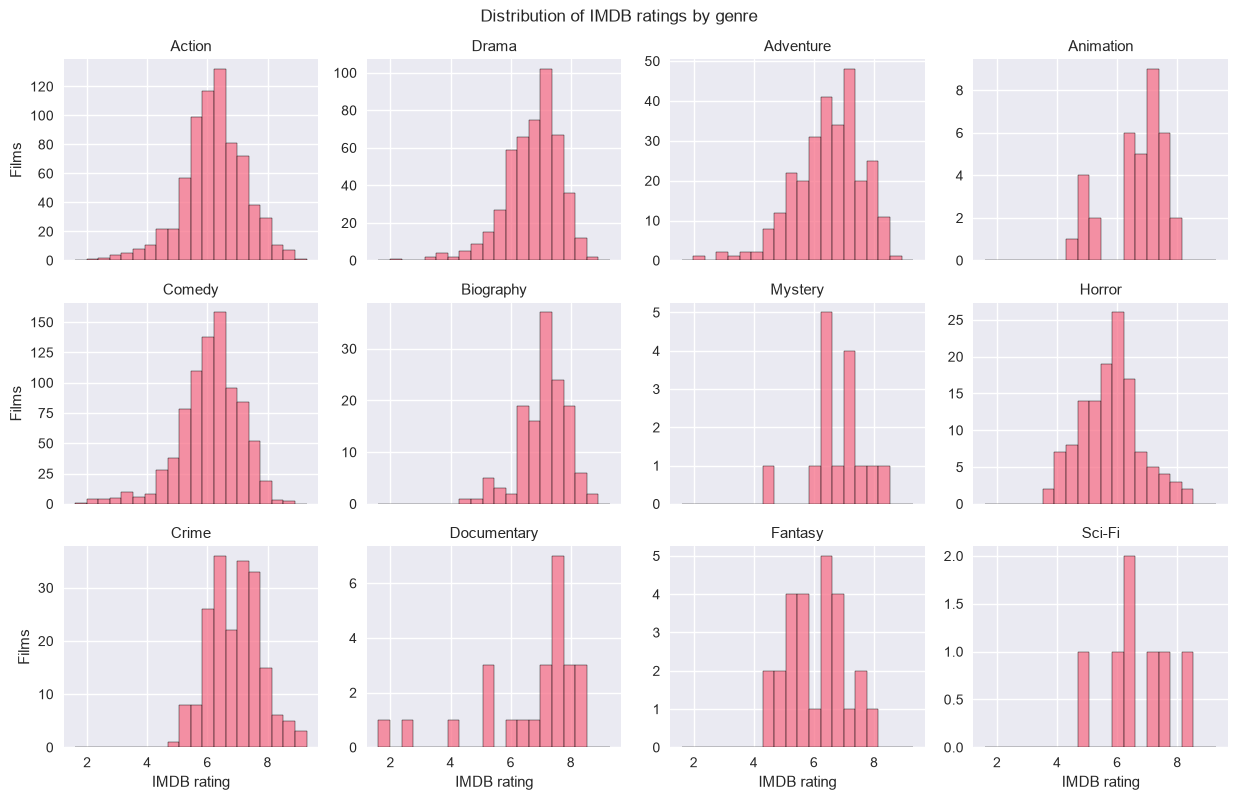

In [9]:
# Histogram of ratings by genre

# Filter for genres that have at least 5 movies: a density curve drawn through
# one or two points describes nothing.
genre_sizes = movies_clean["genre"].value_counts()
big_genres = genre_sizes[genre_sizes >= 5].index

ratings_plot_data = movies_clean[movies_clean["genre"].isin(big_genres)]
print(f"Keeping {len(big_genres)} of {len(genre_sizes)} genres "
      f"({len(ratings_plot_data)} of {len(movies_clean)} films)")

# Plot all the histograms together instead of one after another, using
# seaborn's FacetGrid via displot.
g = sns.displot(
    data=ratings_plot_data,
    x="rating",
    col="genre",
    col_wrap=4,
    bins=20,
    height=2.6,
    aspect=1.2,
    facet_kws={"sharey": False},   # genres differ hugely in size
)
g.set_titles("{col_name}")
g.set_axis_labels("IMDB rating", "Films")
g.figure.suptitle("Distribution of IMDB ratings by genre", y=1.02)
plt.show()

Ratings sit in a narrow band: every genre with a meaningful sample averages between 5.8 and 7.1, so genre explains far less about a film's rating than one might expect.

**Biography rates highest** (mean 7.11, median 7.20) and **Horror lowest** (5.79). The spread matters as much as the average — Documentary has a standard deviation of 1.77, by far the widest, and a range from 1.6 to 8.5: audiences either rate a documentary highly or ignore it, with little in between. Action and Comedy, the two biggest genres, sit lowest among the large groups at 6.23 and 6.11.

Note the `NaN` in the `std` column for Thriller: standard deviation is undefined for a single observation, which is a useful reminder that the small genres carry no information at all.

## Use `seaborn` to answer the following:

### Gross vs. cast Facebook likes

-   Examine the relationship between `gross` and `cast_facebook_likes`. Produce a scatterplot and write one sentence discussing whether the number of facebook likes that the cast has received is likely to be a good predictor of how much money a movie will make at the box office. What variable are you going to map to the Y- and X- axes?

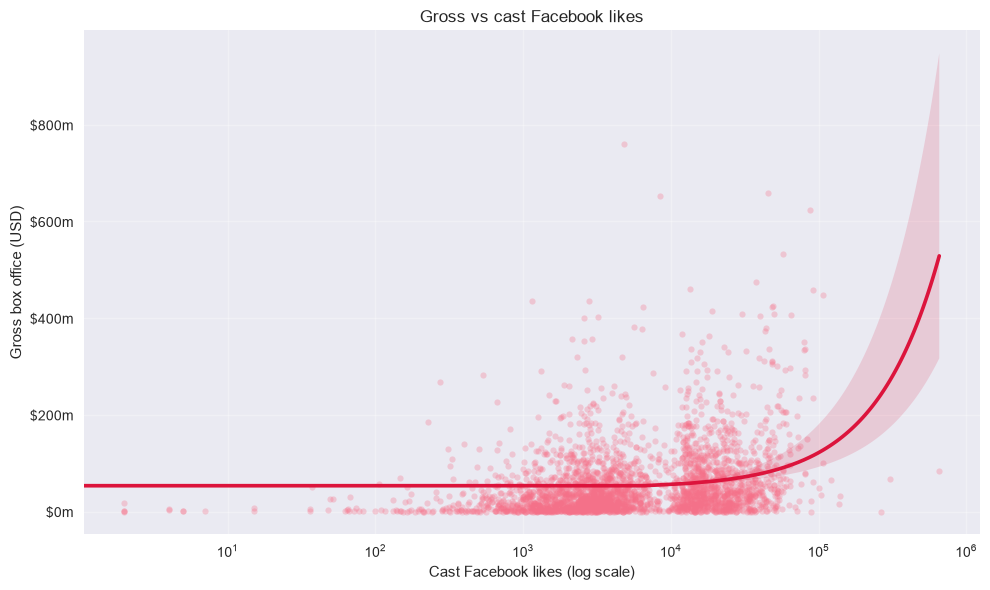

Correlation between gross and cast facebook likes: 0.208


In [10]:
# Scatter plot: Gross vs Cast Facebook Likes

# gross goes on the Y axis because it is the outcome we would want to predict;
# cast_facebook_likes goes on X because it is the candidate predictor.
plt.figure(figsize=(10, 6))

sns.regplot(
    data=movies_clean,
    x="cast_facebook_likes",
    y="gross",
    scatter_kws={"alpha": 0.3, "s": 20},
    line_kws={"color": "crimson"},
)

plt.xscale("log")          # likes span several orders of magnitude
plt.xlabel("Cast Facebook likes (log scale)")
plt.ylabel("Gross box office (USD)")
plt.title("Gross vs cast Facebook likes")
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${v/1e6:,.0f}m"))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Correlation Calculation ---
correlation = movies_clean["gross"].corr(movies_clean["cast_facebook_likes"])

print(f"Correlation between gross and cast facebook likes: {correlation:.3f}")

**Gross belongs on the Y axis and likes on the X axis**, because the question is whether likes help predict revenue, and by convention the outcome goes on Y.

The correlation is **0.21** — positive but weak. The cloud is a shapeless blob: at any level of Facebook likes you can find films that made almost nothing and films that made hundreds of millions. Cast popularity on social media is a poor predictor of box office on its own.

There is also a timing problem that the correlation cannot show. Facebook likes were counted when the data was scraped, years after most of these films were released, so a star's follower count partly *reflects* the success of the film rather than causing it. Even the weak relationship visible here should not be read as cause and effect.

### Gross vs. budget

-   Examine the relationship between `gross` and `budget`. Produce a scatterplot and write one sentence discussing whether budget is likely to be a good predictor of how much money a movie will make at the box office.

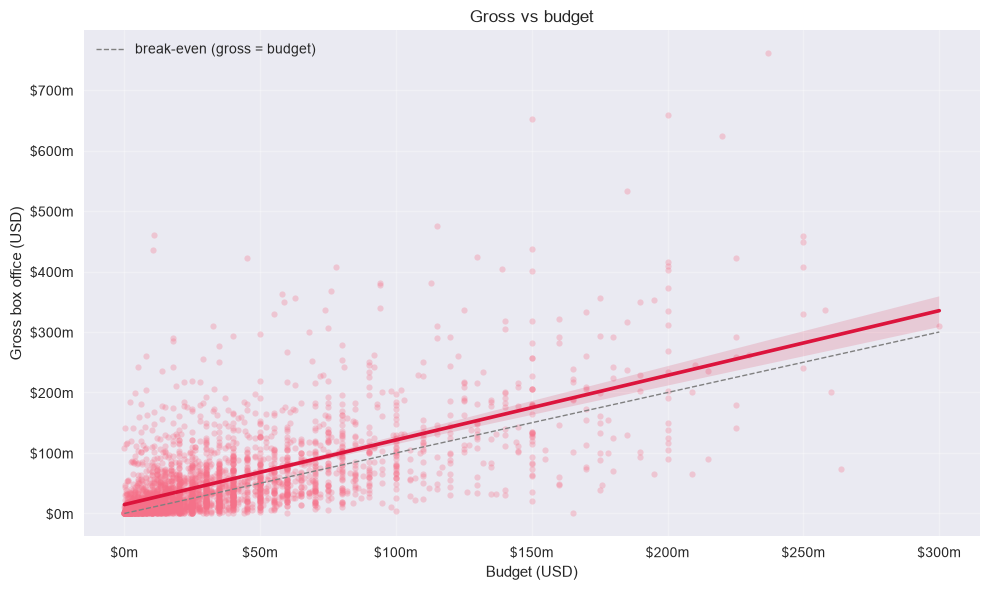

Correlation between gross and budget: 0.639
Films grossing less than their budget: 42%


In [11]:
# Scatter plot: Gross vs Budget

plt.figure(figsize=(10, 6))

sns.regplot(
    data=movies_clean,
    x="budget",
    y="gross",
    scatter_kws={"alpha": 0.3, "s": 20},
    line_kws={"color": "crimson"},
)

# Break-even line: everything below it lost money at the box office.
lims = [0, movies_clean["budget"].max()]
plt.plot(lims, lims, linestyle="--", color="grey", linewidth=1, label="break-even (gross = budget)")
plt.legend()

plt.xlabel("Budget (USD)")
plt.ylabel("Gross box office (USD)")
plt.title("Gross vs budget")
fmt = mtick.FuncFormatter(lambda v, _: f"${v/1e6:,.0f}m")
plt.gca().xaxis.set_major_formatter(fmt)
plt.gca().yaxis.set_major_formatter(fmt)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr_budget = movies_clean["gross"].corr(movies_clean["budget"])
loss_share = (movies_clean["gross"] < movies_clean["budget"]).mean()

print(f"Correlation between gross and budget: {corr_budget:.3f}")
print(f"Films grossing less than their budget: {loss_share:.0%}")

Budget is the **best predictor of the three**, with a correlation of **0.64**, and the relationship is visible rather than imagined: bigger budgets do produce bigger box office on average.

Two caveats keep it from being a rule. The spread widens as budgets grow — expensive films are not merely better on average, they are also more variable, with both the biggest hits and the biggest disasters. And **42% of films in this dataset grossed less than their budget**, which is what the dashed break-even line shows: nearly half the points sit below it.

Direction of causation is not settled by this plot either. Studios commit large budgets to properties they already expect to sell — a known franchise, a bankable star — so part of what looks like "spending buys revenue" is really "expected revenue justifies spending".

### Gross vs. rating, faceted by genre

-   Examine the relationship between `gross` and `rating`. Produce a scatterplot, faceted by `genre` and discuss whether IMDB ratings are likely to be a good predictor of how much money a movie will make at the box office. Is there anything strange in this dataset?

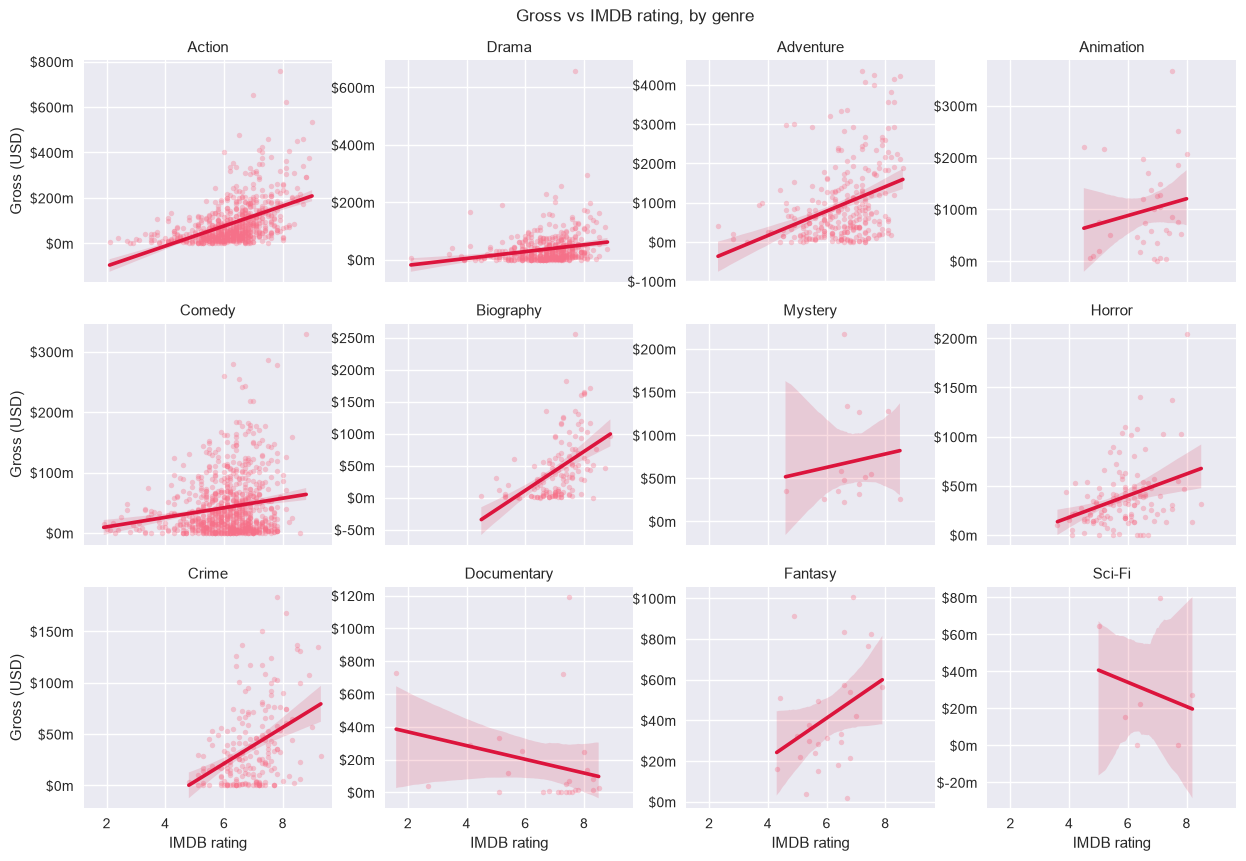

Overall correlation between gross and rating: 0.274


In [12]:
# Scatter plot: Gross vs Rating by Genre- for genres that have at least 5 movies

gross_rating_data = movies_clean[movies_clean["genre"].isin(big_genres)]

g = sns.lmplot(
    data=gross_rating_data,
    x="rating",
    y="gross",
    col="genre",
    col_wrap=4,
    height=2.8,
    aspect=1.1,
    scatter_kws={"alpha": 0.35, "s": 15},
    line_kws={"color": "crimson"},
    facet_kws={"sharey": False},
)
g.set_titles("{col_name}")
g.set_axis_labels("IMDB rating", "Gross (USD)")
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${v/1e6:,.0f}m"))
g.figure.suptitle("Gross vs IMDB rating, by genre", y=1.02)
plt.show()

print(f"Overall correlation between gross and rating: "
      f"{movies_clean['gross'].corr(movies_clean['rating']):.3f}")

Overall the correlation between rating and gross is **0.27** — weak, and the facets show it is not even consistent in direction. Action, Adventure and Animation slope up reasonably clearly; Documentary and Mystery are flat or slope down. Being well reviewed and being commercially successful are close to independent, which is not surprising once you notice that a rating is an average of opinions from people who already chose to watch the film.

**What is strange in this dataset**, in rough order of how much it should worry you:

1. **Each film has exactly one genre.** IMDB assigns several, so a single label has been picked somehow. That makes every genre-level comparison on this page cruder than it appears, and it explains why some facets look oddly homogeneous.
2. **Genre groups are wildly unbalanced** — 844 Comedies against a single Thriller. Five genres had to be dropped before plotting, and even among those kept, Sci-Fi has seven films.
3. **The 54 duplicate records** found at the start, identical except for a few votes: evidence the file was assembled by scraping rather than from a clean source.
4. **Gross is not adjusted for inflation**, as the data dictionary states, while the films span **1920 to 2016**. A dollar in 1975 is not a dollar in 2015, so every comparison across eras is distorted, and older films are systematically understated.
5. **Gross appears to be US box office only.** For films that made most of their money abroad the figure understates real revenue, which will affect the return-on-budget table above.

# Returns of financial stocks

> You may find useful the material on [finance data sources](https://am01-sep24.netlify.app/reference/finance_data/).

We will use the `yfinance` package to download historical data of stock prices, calculate returns, and examine the distribution of returns.

We must first identify which stocks we want to download data for, and for this we must know their ticker symbol; Apple is known as AAPL, Microsoft as MSFT, McDonald's as MCD, etc. The file `nyse.csv` contains 508 stocks listed on the NYSE, their ticker `symbol`, `name`, the IPO (Initial Public Offering) year, and the sector and industry the company is in.



In [13]:
# Load NYSE data

# Load the dataset from the relevant directory


from pathlib import Path

RAW = "https://raw.githubusercontent.com/kostis-christodoulou/am01-code-sep2026/main/data"
local = Path("../data/nyse.csv")


nyse = pd.read_csv(local if local.exists() else f"{RAW}/nyse.csv")


# Printing out the first 10 observations
nyse.head()

# Printing out information of the dataset's variables
print("nData info: ")

nyse.info()

nData info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   symbol         508 non-null    object 
 1   name           508 non-null    object 
 2   ipo_year       143 non-null    float64
 3   sector         508 non-null    object 
 4   industry       508 non-null    object 
 5   summary_quote  508 non-null    object 
dtypes: float64(1), object(5)
memory usage: 23.9+ KB


## Companies per sector

Based on this dataset, create a table and a bar plot that shows the number of companies per sector, in descending order

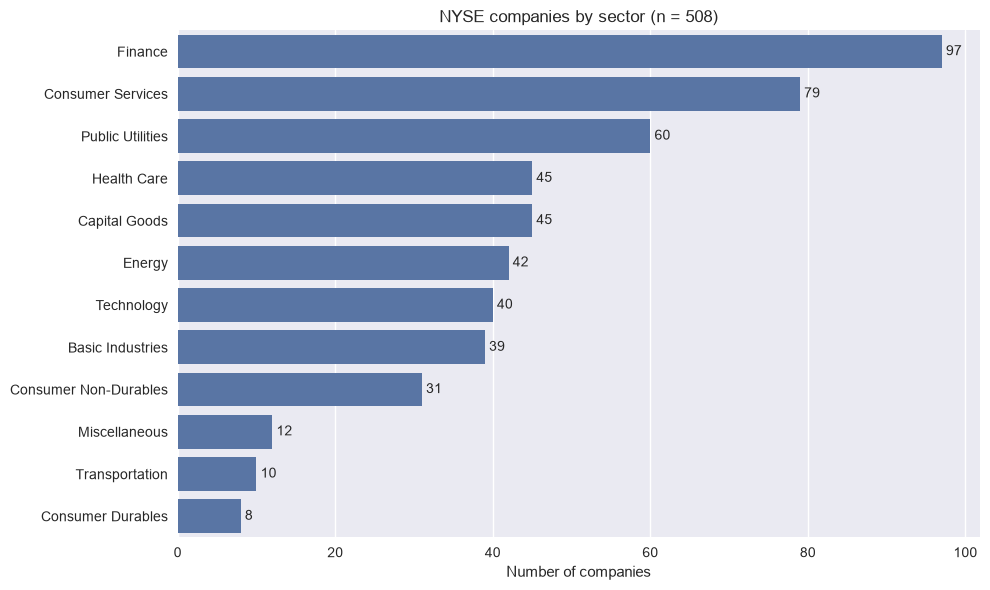

In [14]:
# Companies per sector

# value_counts() counts the rows in each sector and already sorts them descending.
sector_counts = (
    nyse["sector"]
    .value_counts()
    .reset_index(name="companies")
)

sector_counts


# Bar plot
# Sectors go on the y-axis: the names are long and would overlap horizontally.
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=sector_counts, x="companies", y="sector", color="#4C72B0")
ax.bar_label(ax.containers[0], padding=3, fontsize=10)
ax.set(
    xlabel="Number of companies",
    ylabel="",
    title=f"NYSE companies by sector (n = {sector_counts['companies'].sum()})",
)
sns.despine(left=True)
plt.tight_layout()
plt.show()

## Choose stocks and download data

Next, let's choose some stocks and their ticker symbols and download some data. You **MUST** choose 6 different stocks from the ones listed below; You should, however, add `SPY` which is the SP500 ETF (Exchange Traded Fund).

In [15]:
# Download stock data

# The 6 chosen stocks plus SPY (the S&P 500 ETF)
# Six stocks picked from nyse.csv across six different sectors, so the
# risk-return comparison is not just one industry, plus SPY as the benchmark.
#   JPM  Finance                | XOM  Energy
#   KO   Consumer Non-Durables  | JNJ  Health Care
#   NKE  Consumer Non-Durables  | CCL  Consumer Services (cruise line)
my_stocks = ["JPM", "XOM", "KO", "JNJ", "NKE", "CCL", "SPY"]

# Date range: start on 1 January five years ago, end today.
# Computed from today's date so it always stays current when re-run.
end_date = pd.Timestamp.today().normalize()
start_date = pd.Timestamp(year=end_date.year - 5, month=1, day=1)

# Download every ticker in ONE call. Passing a list to yf.download returns a
# frame with a two-level column index (field, ticker); selecting "Adj Close"
# collapses it to a tidy price matrix: dates on the index, one column per stock.
prices = yf.download(
    my_stocks,
    start=start_date,
    end=end_date,
    auto_adjust=False,   # keep the explicit "Adj Close" column
    progress=False,
)["Adj Close"]

# yfinance returns the columns alphabetically, so reorder to match our list.
prices = prices[my_stocks]

print(f"Downloaded {start_date.date()} to {end_date.date()}")
print("Adjusted-close price matrix:", prices.shape)   # (trading days, stocks)
prices.head()

Downloaded 2021-01-01 to 2026-08-25
Adjusted-close price matrix: (1416, 7)


Ticker,JPM,XOM,KO,JNJ,NKE,CCL,SPY
Date,,,,,,,
2021-01-04,109.000519,33.251331,44.792786,134.287399,128.455643,20.057678,342.436920
2021-01-05,109.593651,34.853802,44.300358,135.866180,129.491714,20.274200,344.795471
2021-01-06,114.739693,35.743172,42.891045,137.144730,130.518631,20.077364,346.856842
2021-01-07,118.507637,36.023609,42.415604,137.608078,132.902557,20.411985,352.010193
2021-01-08,118.638474,36.424213,43.366478,137.324905,134.186157,20.146255,354.015869


## Calculate daily and monthly returns

Financial performance analysis depend on returns; If I buy a stock today for 100 and I sell it tomorrow for 101.75, my one-day return, assuming no transaction costs, is 1.75%. So given the adjusted closing prices, our first step is to calculate daily and monthly returns.

In [16]:
# Calculate returns

# pct_change() on the whole DataFrame computes returns for every stock at once.
daily_returns = prices.pct_change()

# Resample to month-end ("ME") / year-end ("YE"), take the last price in each
# period, then compute the percentage change. (Older pandas uses "M" / "Y".)
monthly_returns = prices.resample("ME").last().pct_change()
yearly_returns  = prices.resample("YE").last().pct_change()

monthly_returns.head()

Ticker,JPM,XOM,KO,JNJ,NKE,CCL,SPY
Date,,,,,,,
2021-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-28,0.143778,0.233125,0.017445,-0.022570,0.010959,0.432780,0.027806
2021-03-31,0.034382,0.026853,0.084889,0.037170,-0.014023,-0.007850,0.045399
2021-04-30,0.016330,0.025255,0.024094,-0.009857,-0.002032,0.053504,0.052910
2021-05-31,0.067811,0.034597,0.024268,0.046555,0.031031,0.057225,0.006566


## Summary of monthly returns

Create a table where you summarise monthly returns for each of the stocks and `SPY`; min, max, median, mean, SD.

In [17]:
# Summary of monthly returns

# .agg() applies all five statistics to every column in one shot; .T puts the
# stocks on the rows and the statistics on the columns.
monthly_summary = (
    monthly_returns
    .agg(["min", "max", "median", "mean", "std"])
    .T
    .round(4)
)

print("Monthly returns summary:")
monthly_summary

Monthly returns summary:


,min,max,median,mean,std
Ticker,,,,,
JPM,-0.1484,0.2154,0.0234,0.0196,0.0680
XOM,-0.1291,0.2692,0.0253,0.0259,0.0803
KO,-0.0911,0.1289,0.0162,0.0132,0.0468
JNJ,-0.0860,0.1271,0.0085,0.0113,0.0504
NKE,-0.2169,0.1835,-0.0068,-0.0121,0.0910
CCL,-0.3768,0.6768,-0.0028,0.0190,0.1750
SPY,-0.0924,0.1051,0.0210,0.0129,0.0439


## Density plot of monthly returns

Plot a density plot, using `sns.kdeplot()`, for each of the stocks

Text(0.5, 1.02, 'Density of Monthly Returns by Stock')

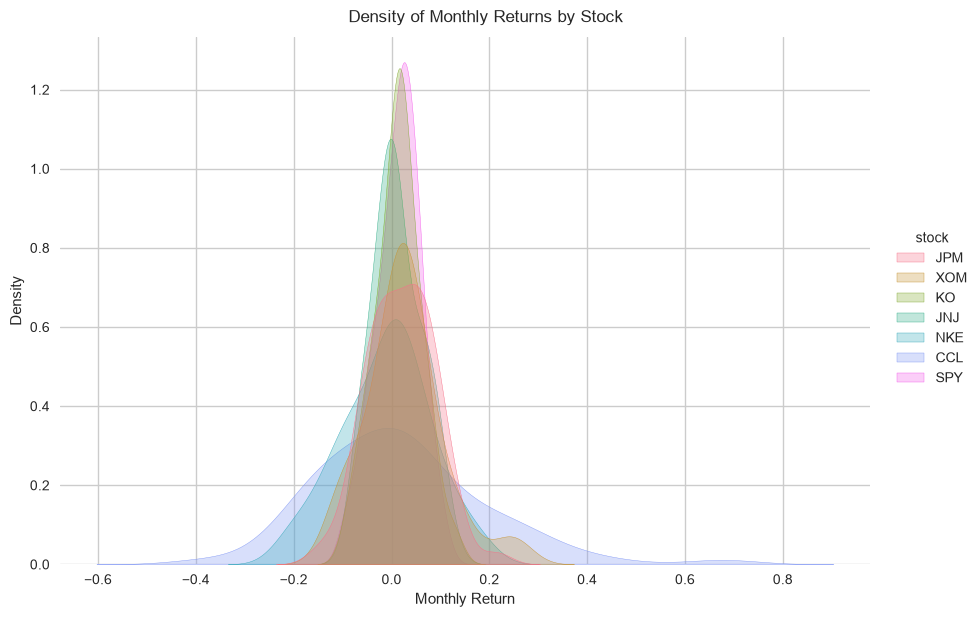

In [18]:
# Density plot of monthly returns

# Reshape to long ("tidy") form so seaborn can colour by stock with `hue`:
# one row per (date, stock, monthly_return).
monthly_long = (
    monthly_returns
    .melt(value_name="monthly_return", var_name="stock", ignore_index=False)
    .dropna()
)

sns.set_style("whitegrid")

# displot draws every stock's KDE on a single seaborn figure, no manual loop.
g = sns.displot(
    data=monthly_long,
    x="monthly_return",
    hue="stock",
    kind="kde",
    fill=True,
    alpha=0.3,
    height=6,
    aspect=1.5,
)
g.set_axis_labels("Monthly Return", "Density")
g.fig.suptitle("Density of Monthly Returns by Stock", y=1.02)

What can you infer from this plot? Which stock is the riskiest? The least risky?

> TYPE YOUR ANSWER AFTER (AND OUTSIDE!) THIS BLOCKQUOTE.

What matters here is the **width** of each curve, not its height. A narrow, tall curve means monthly returns cluster tightly around the average; a wide, flat one means the outcome varies a lot from month to month. Width is exactly what the standard deviation in the summary table measures, so the plot and the table tell the same story in two ways.

**Least risky: SPY**, with a monthly standard deviation of 4.4% and a range of only -9.2% to +10.5%. That is the whole point of an index fund — it holds around 500 companies, so a disaster at any single one barely moves the total. Among the individual stocks, KO is the tightest (4.7%), with JNJ just behind (5.0%); a soft-drinks company and a healthcare company both sell things people keep buying in a downturn.

**Riskiest: CCL** by a wide margin — a standard deviation of 17.5%, nearly four times SPY's, with monthly returns running from -37.7% to +67.7%. Carnival is a cruise operator: heavily indebted, highly sensitive to fuel prices, consumer confidence and travel restrictions, and this five-year window covers both the collapse in travel and the rebound afterwards. NKE is the second widest (9.1%).

The ordering is intuitive once you look at what these businesses actually do. Discretionary spending on holidays and trainers swings hard with the economic cycle; fizzy drinks and painkillers do not.

## Risk-return plot

Finally, make a plot that shows the expected monthly return (mean) of a stock on the Y axis and the risk (standard deviation) in the X-axis. Please use `plt.annotate()` to label each stock

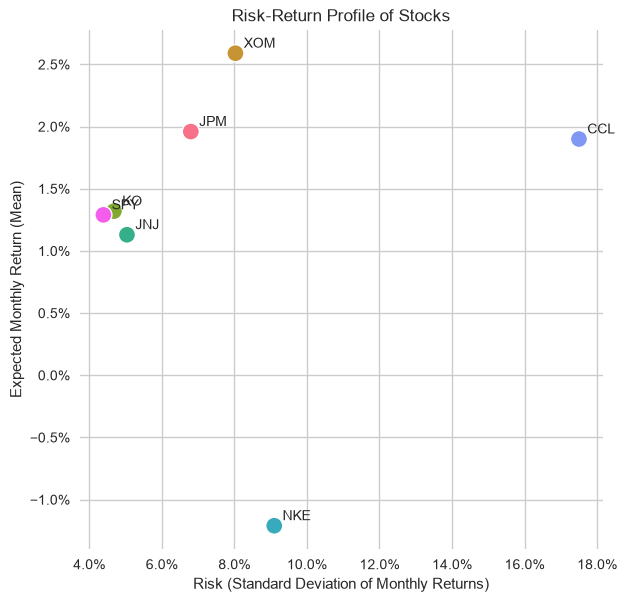

In [19]:
# Risk-return plot
# monthly_summary already holds each stock's mean (return) and std (risk),
# so we can plot straight from it. reset_index turns the ticker into a column.
risk_return = monthly_summary.reset_index(names="stock")

sns.set_style("whitegrid")
ax = sns.scatterplot(
    data=risk_return,
    x="std",
    y="mean",
    hue="stock",
    s=150,
    legend=False,
)

# Label each point, one annotation per row.
for row in risk_return.itertuples():
    ax.annotate(row.stock, (row.std, row.mean),
                xytext=(6, 4), textcoords="offset points")

ax.set(
    xlabel="Risk (Standard Deviation of Monthly Returns)",
    ylabel="Expected Monthly Return (Mean)",
    title="Risk-Return Profile of Stocks",
)

# Format both axes as percentages with one decimal (values are decimals, so xmax=1).
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))

What can you infer from this plot? Are there any stocks which, while being riskier, do not have a higher expected return?

> TYPE YOUR ANSWER AFTER (AND OUTSIDE!) THIS BLOCKQUOTE

The textbook expectation is that points line up from bottom-left to top-right: take on more risk, get paid more for it. That broadly holds here — XOM sits top-right (2.6% mean return for 8.0% risk) and JNJ bottom-left (1.1% for 5.0%) — but two stocks clearly break the pattern.

**NKE is the clearest failure.** Its risk is 9.1%, more than double SPY's, and its average monthly return over these five years is **negative**, at -1.2%. Investors carried twice the volatility of the market and ended up worse off than holding cash.

**CCL is the second.** It is the riskiest stock in the set by a distance (17.5%), yet its 1.9% average return is essentially the same as JPM's 2.0%, which comes with less than half the volatility (6.8%). The extra risk bought nothing.

A quick way to rank these is return per unit of risk (mean ÷ standard deviation):

| | XOM | SPY | JPM | KO | JNJ | CCL | NKE |
|---|---|---|---|---|---|---|---|
| mean/SD | 0.32 | 0.29 | 0.29 | 0.28 | 0.22 | 0.11 | -0.13 |

Only XOM beat the index on this measure, and only narrowly. Four of the six individual stocks did worse than simply buying SPY — which is the practical argument for diversification: picking single names added risk without reliably adding return.

One caveat on reading too much into this. The sample is 67 monthly observations from one particular five-year window, and averages over such a short period are noisy. CCL's +67.7% best month is a post-pandemic rebound, not a repeatable feature, and a different start date would reshuffle the ranking. The relative *risk* ordering is far more stable across periods than the return ordering.

# Rents in San Francisco 2000-2018

[Kate Pennington](https://www.katepennington.org/data) created a panel of historic Craigslist rents by scraping posts archived by the Wayback Machine. You can read more about her work here:

[What impact does new housing have on rents, displacement, and gentrification in the surrounding neighborhood? Read our interview with economist Kate Pennington about her article, \"Does Building New Housing Cause Displacement?:The Supply and Demand Effects of Construction in San Francisco.\"](https://matrix.berkeley.edu/research-article/kate-pennington-on-gentrification-and-displacement-in-san-francisco/)

In our case, we have a clean(ish) dataset with about 200K rows that correspond to Craigslist listings for renting properties in the greater SF area. The data dictionary is as follows:

| variable    | class     | description           |
|-------------|-----------|-----------------------|
| post_id     | character | Unique ID             |
| date        | double    | date                  |
| year        | double    | year                  |
| nhood       | character | neighborhood          |
| city        | character | city                  |
| county      | character | county                |
| price       | double    | price in USD          |
| beds        | double    | n of beds             |
| baths       | double    | n of baths            |
| sqft        | double    | square feet of rental |
| room_in_apt | double    | room in apartment     |
| address     | character | address               |
| lat         | double    | latitude              |
| lon         | double    | longitude             |
| title       | character | title of listing      |
| descr       | character | description           |
| details     | character | additional details    |

The dataset was used in a recent [tidyTuesday](https://github.com/rfordatascience/tidytuesday) project.

In [20]:
# Download rent data

rent = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2022/2022-07-05/rent.csv')

print("Data shape:", rent.shape)

print("\nData info:")

# Printing the dataset's variables, their data types etc.
print(rent.info())

Data shape: (200796, 17)

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200796 entries, 0 to 200795
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   post_id      200796 non-null  object 
 1   date         200796 non-null  int64  
 2   year         200796 non-null  int64  
 3   nhood        200796 non-null  object 
 4   city         200796 non-null  object 
 5   county       199402 non-null  object 
 6   price        200796 non-null  int64  
 7   beds         194188 non-null  float64
 8   baths        42675 non-null   float64
 9   sqft         64679 non-null   float64
 10  room_in_apt  200796 non-null  int64  
 11  address      3908 non-null    object 
 12  lat          7651 non-null    float64
 13  lon          4312 non-null    float64
 14  title        198279 non-null  object 
 15  descr        3254 non-null    object 
 16  details      8016 non-null    object 
dtypes: float64(5), int64(4), objec

## Variable types and missing values

What are the variable types? Do they all correspond to what they really are? Which variables have most missing values?

In [21]:
# Data inspection

# Calculating the total no. of missing values in each column of the dataset


# Sorts variables with missing values in ascending order

# Printing out the datatypes


# Printing out a sample- the first few rows



## Top 20 cities by % of listings

Make a plot that shows the top 20 cities in terms of % of classifieds between 2000-2018. You need to calculate the number of listings by city, and then convert that number to a %.

The final graph should look like this:

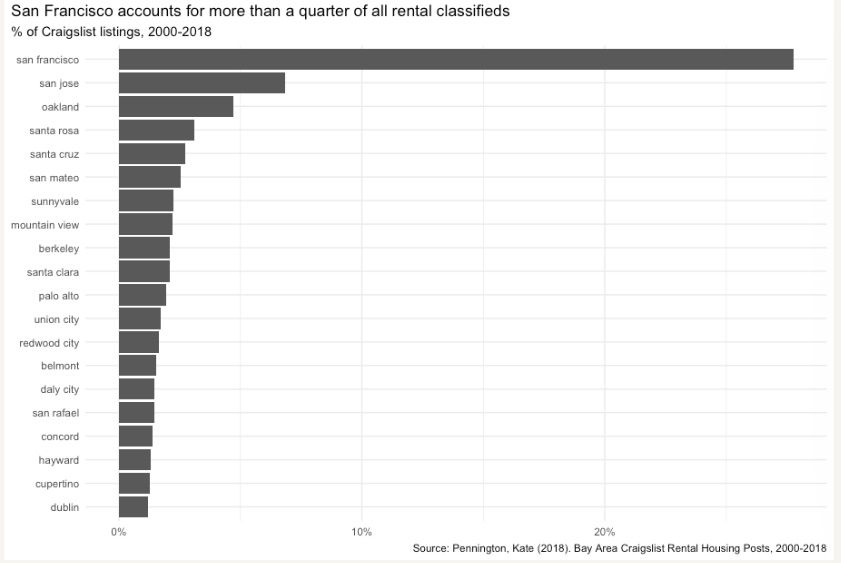

In [22]:
# Top 20 cities by percentage of listings



## Median prices in San Francisco by bedrooms

Make a plot that shows the evolution of median prices in San Francisco for 0, 1, 2, and 3 bedrooms listings. The final graph should resemble this

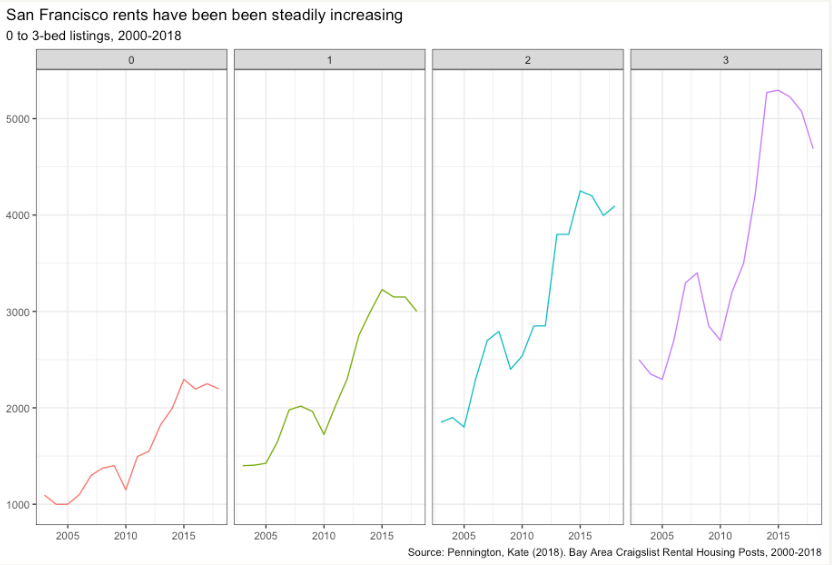

In [23]:
# Time-series of median rents in San Francisco (0-3 bedrooms)

# Data Prep



## Median rents for the top 12 Bay Area cities

Finally, make a plot that shows median rental prices for the top 12 cities in the Bay area (for 1 bedroom rentals). Your final graph should look like this

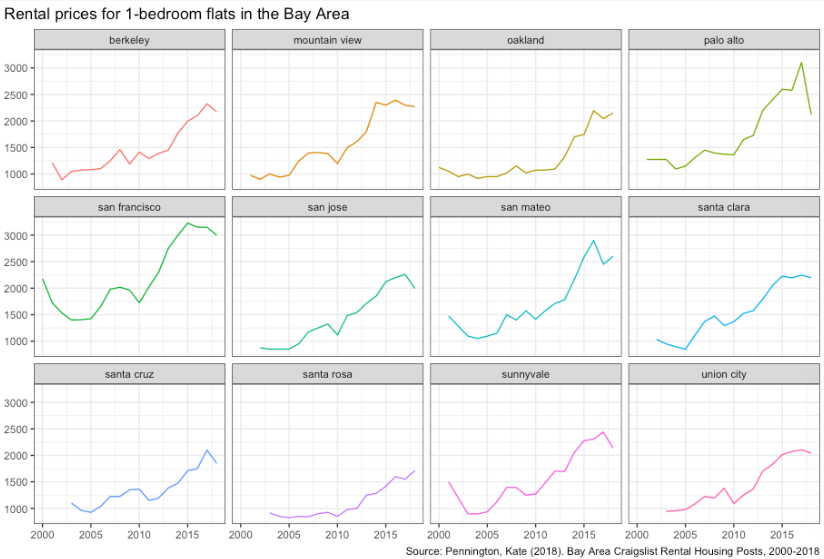

In [24]:
# Median rental prices for top 12 cities (in terms of number of ads) in Bay Area



What can you infer from these plots? Don't just explain what's in the graph, but speculate or tell a short story (1-2 paragraphs max).

> TYPE YOUR ANSWER AFTER (AND OUTSIDE!) THIS BLOCKQUOTE.

# Deliverables

There is a lot of explanatory text, comments, etc. You do not need these, so delete them and produce a stand-alone document that you could share with someone. Save this notebook and upload it to Canvas.

# Details

-   Who did you collaborate with: TYPE NAMES HERE
-   Approximately how much time did you spend on this problem set: ANSWER HERE
-   What, if anything, gave you the most trouble: ANSWER HERE


**Please seek out help when you need it,** and remember the 15-minute rule. You know enough Python (and have enough examples of code from class and your readings) to be able to do this. If you get stuck, ask for help from others, use LLMs at your own risk-- and remember that I am here to help too!

> As a true test to yourself, do you understand the code you submitted and are you able to explain it to someone else?


# Rubric

Check minus (1/5): Displays minimal effort. Doesn't complete all components. Code is poorly written and not documented. Uses the same type of plot for each graph, or doesn't use plots appropriate for the variables being analyzed.

Check (3/5): Solid effort. Hits all the elements. No clear mistakes. Easy to follow (both the code and the output).

Check plus (5/5): Finished all components of the assignment correctly and addressed both challenges. Code is well-documented (both self-documented and with additional comments as necessary). Used pandas with command chaining and seaborn, instead of matplotlib. Graphs and tables are properly labelled. Analysis is clear and easy to follow, either because graphs are labeled clearly or you've written additional text to describe how you interpret the output.